# 读取文件

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('default')
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 300          # 默认 dpi
plt.rcParams['savefig.dpi'] = 300         # 保存时的 dpi（虽说不保存，但也设置）
# plt.rcParams['figure.figsize'] = (12, 6)  # 默认尺寸

df = pd.read_parquet('features_with_riskindex.parquet')
print(f"原始数据形状: {df.shape}")

原始数据形状: (2061226, 17)


# 确定阈值

## MLE法确定触发阈值

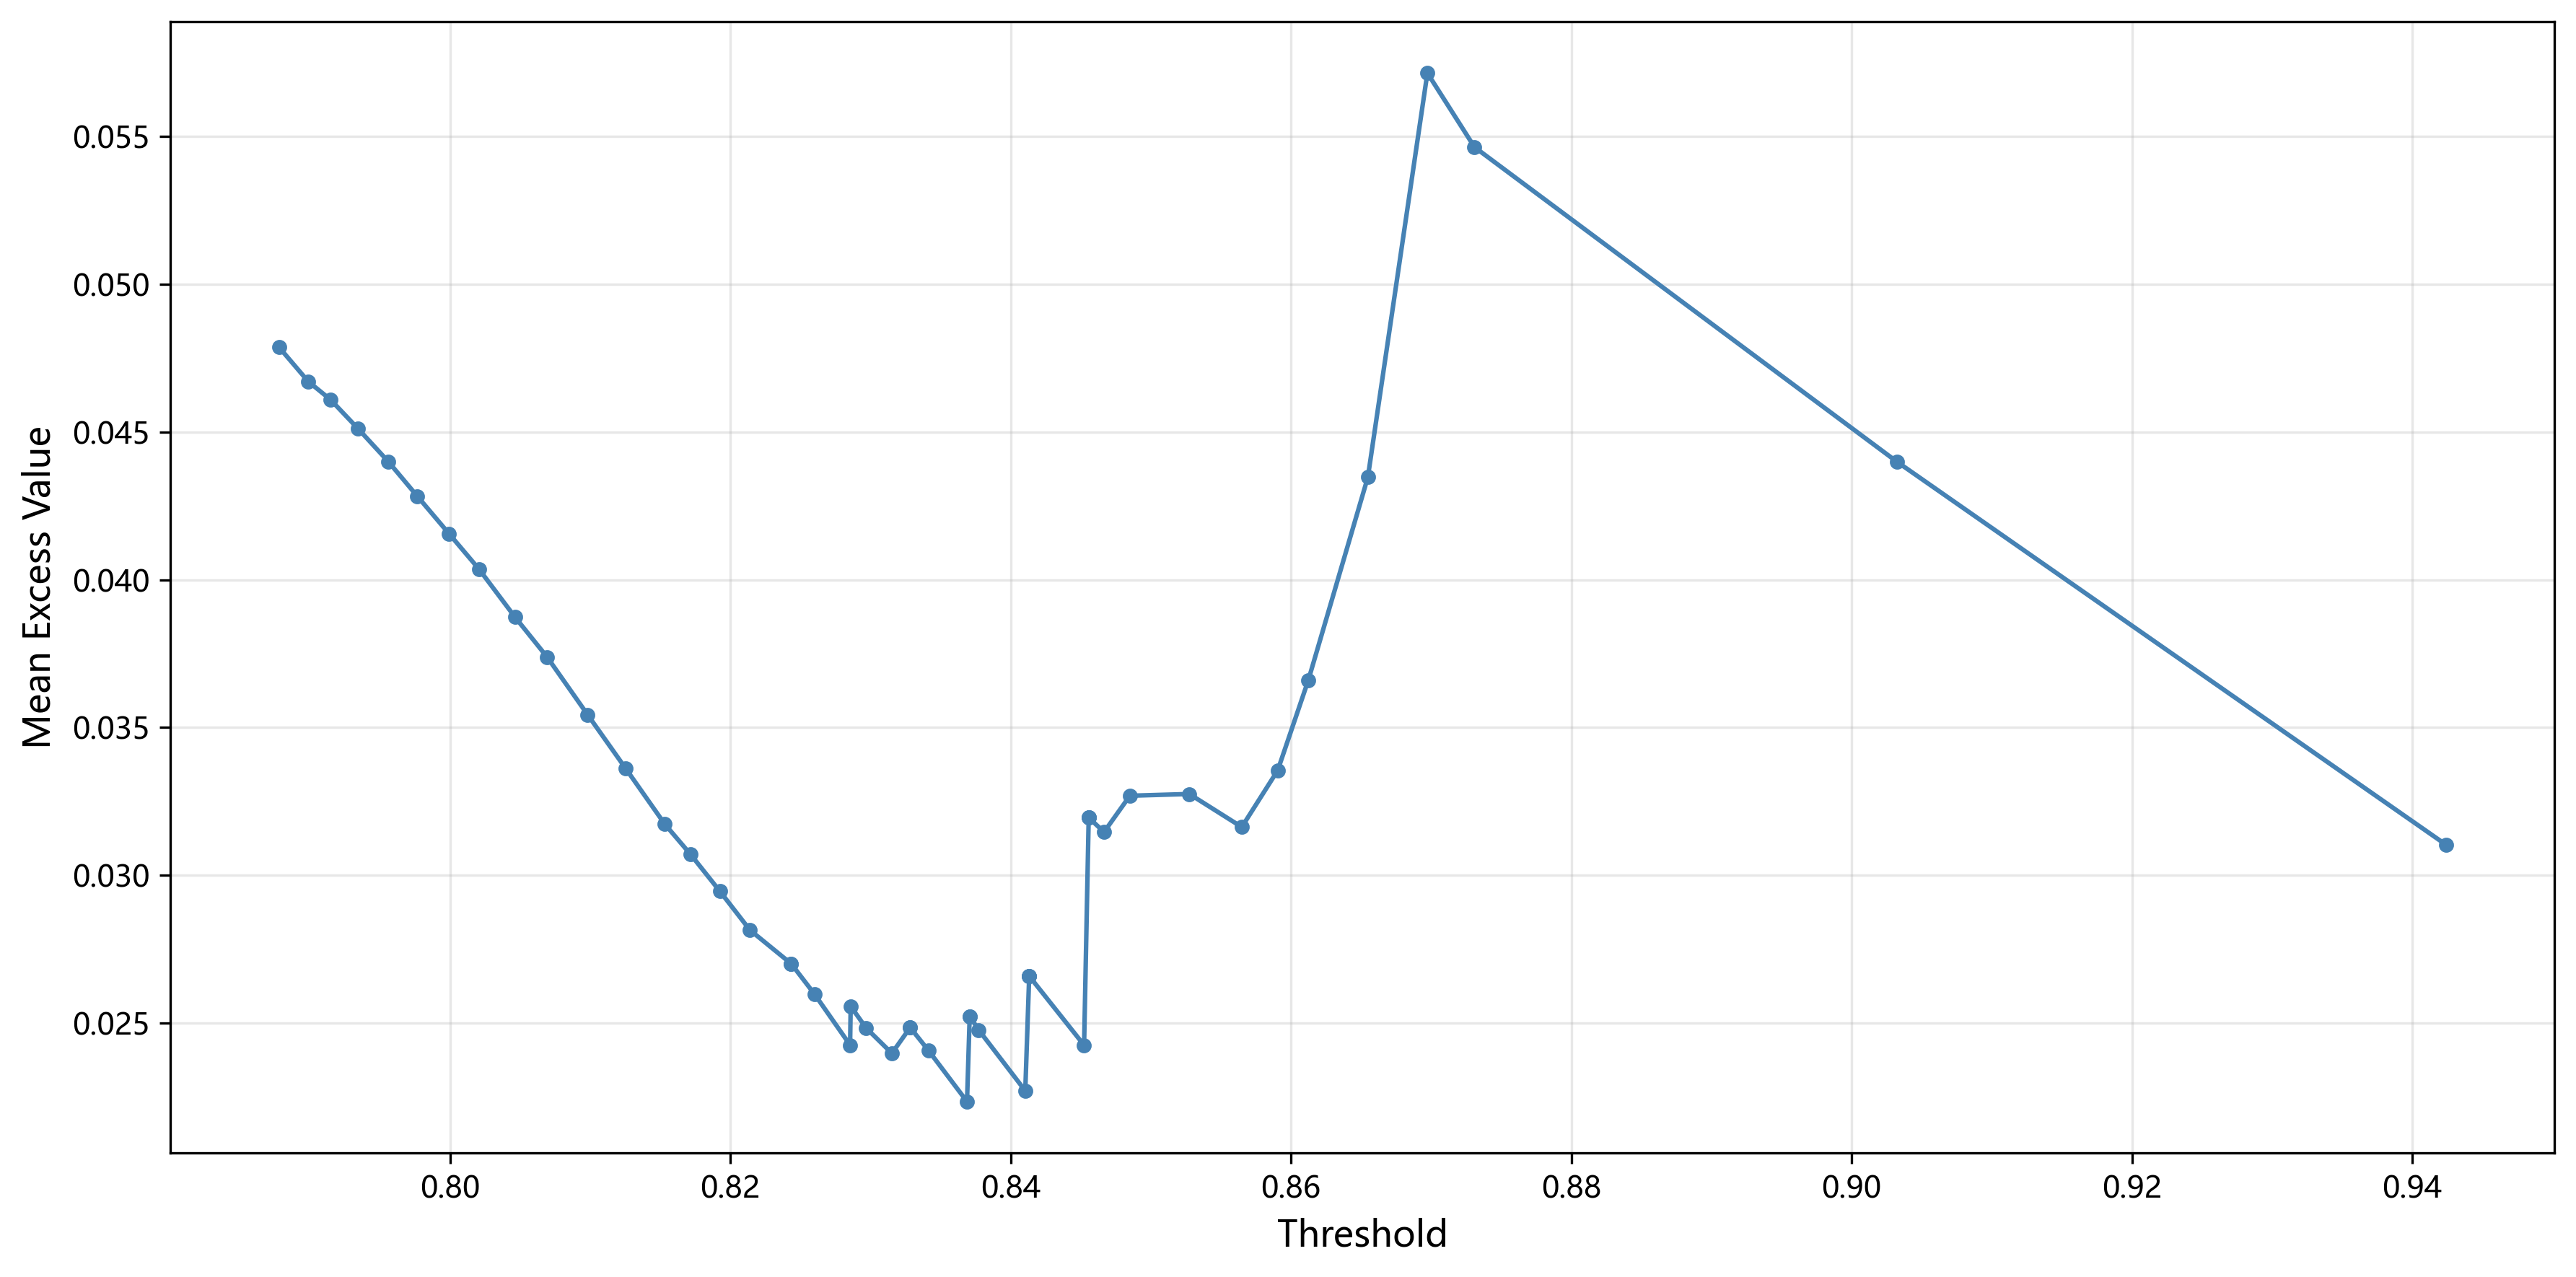

In [5]:
# 提取综合指数，去除缺失值
data = df['norm_risk_score'].dropna().values

# 定义不同阈值（通常取数据的分位数作为候选阈值）
# 为避免极端值影响，从第 90% 分位数到第 100% 分位数之间均匀取点
thresholds = np.percentile(data, np.linspace(99.9, 99.9999, 50))

# 计算每个阈值对应的平均超出量
mean_excess = []
valid_thresholds = []
for u in thresholds:
    exceedances = data[data > u] - u
    if len(exceedances) > 0:
        mean_excess.append(np.mean(exceedances))
        valid_thresholds.append(u)
    else:
        mean_excess.append(np.nan)
        # 注意：对于没有超出值的阈值，不添加到 valid_thresholds

# 绘制平均超出函数图
plt.figure(figsize=(12, 6))
plt.plot(thresholds, mean_excess, 'o-', markersize=4, linewidth=1.5, color='steelblue')
# plt.plot(valid_thresholds, mean_excess, 'o-', markersize=4, linewidth=1.5, color='steelblue')
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Mean Excess Value', fontsize=12)
# plt.title('Mean Excess Function Plot of Lightning Index', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("MEF.pdf", dpi=300)
plt.show()

## 导出MLE统计信息

In [20]:
# 创建DataFrame用于导出
export_df = pd.DataFrame({
    '阈值': thresholds,
    '平均超出量': mean_excess
})

# 导出为CSV文件
csv_filename = 'mean_excess_function_data.csv'
export_df.to_csv(csv_filename, index=False, encoding='utf-8-sig')
print(f"数据已导出至: {csv_filename}")
print(f"共导出 {len(export_df)} 个数据点")
summary_df = pd.DataFrame({
    '统计指标': ['数据总数', '超出事件总数', '阈值范围', '平均超出量范围'],
    '数值': [
        len(data),
        len(valid_thresholds),
        f"{min(valid_thresholds):.4f} ~ {max(valid_thresholds):.4f}",
        f"{min(mean_excess):.4f} ~ {max(mean_excess):.4f}"
    ]
})

summary_df.to_csv('mean_excess_summary.csv', index=False, encoding='utf-8-sig')
print("统计摘要已保存至: mean_excess_summary.csv")

数据已导出至: mean_excess_function_data.csv
共导出 50 个数据点
统计摘要已保存至: mean_excess_summary.csv


## 绘制Hill图

In [7]:
import numpy as np
import pandas as pd

data = df['norm_risk_score'].dropna().values

# 平移处理（同原代码）
if np.min(data) <= 0:
    shift = -np.min(data) + 1e-6
    data = data + shift
    print(f"已平移 {shift:.6f}")

# 排序（这一步最耗时，但必须）
sorted_data = np.sort(data)[::-1]
n = len(sorted_data)  # 约206万

# 关键改进：k不用密集采样
k_min = int(0.00003 * n)   # 1% 约2万个
k_max = int(0.0001 * n)    # 30% 约62万个，Hill通常看前10-30%
step = max(1, (k_max - k_min) // 200)  # 取200个点
k_values = list(range(k_min, k_max + 1, step))

# 向量化计算（比循环快很多）
hill_estimates = []
thresholds = []

for k in k_values:
    x_k1 = sorted_data[k]  # 阈值
    # 向量化计算前k个的对数和
    log_sum = np.sum(np.log(sorted_data[:k] / x_k1))
    h = log_sum / k
    hill_estimates.append(h)
    thresholds.append(x_k1)

已平移 0.000001


### 可视化与数据输出

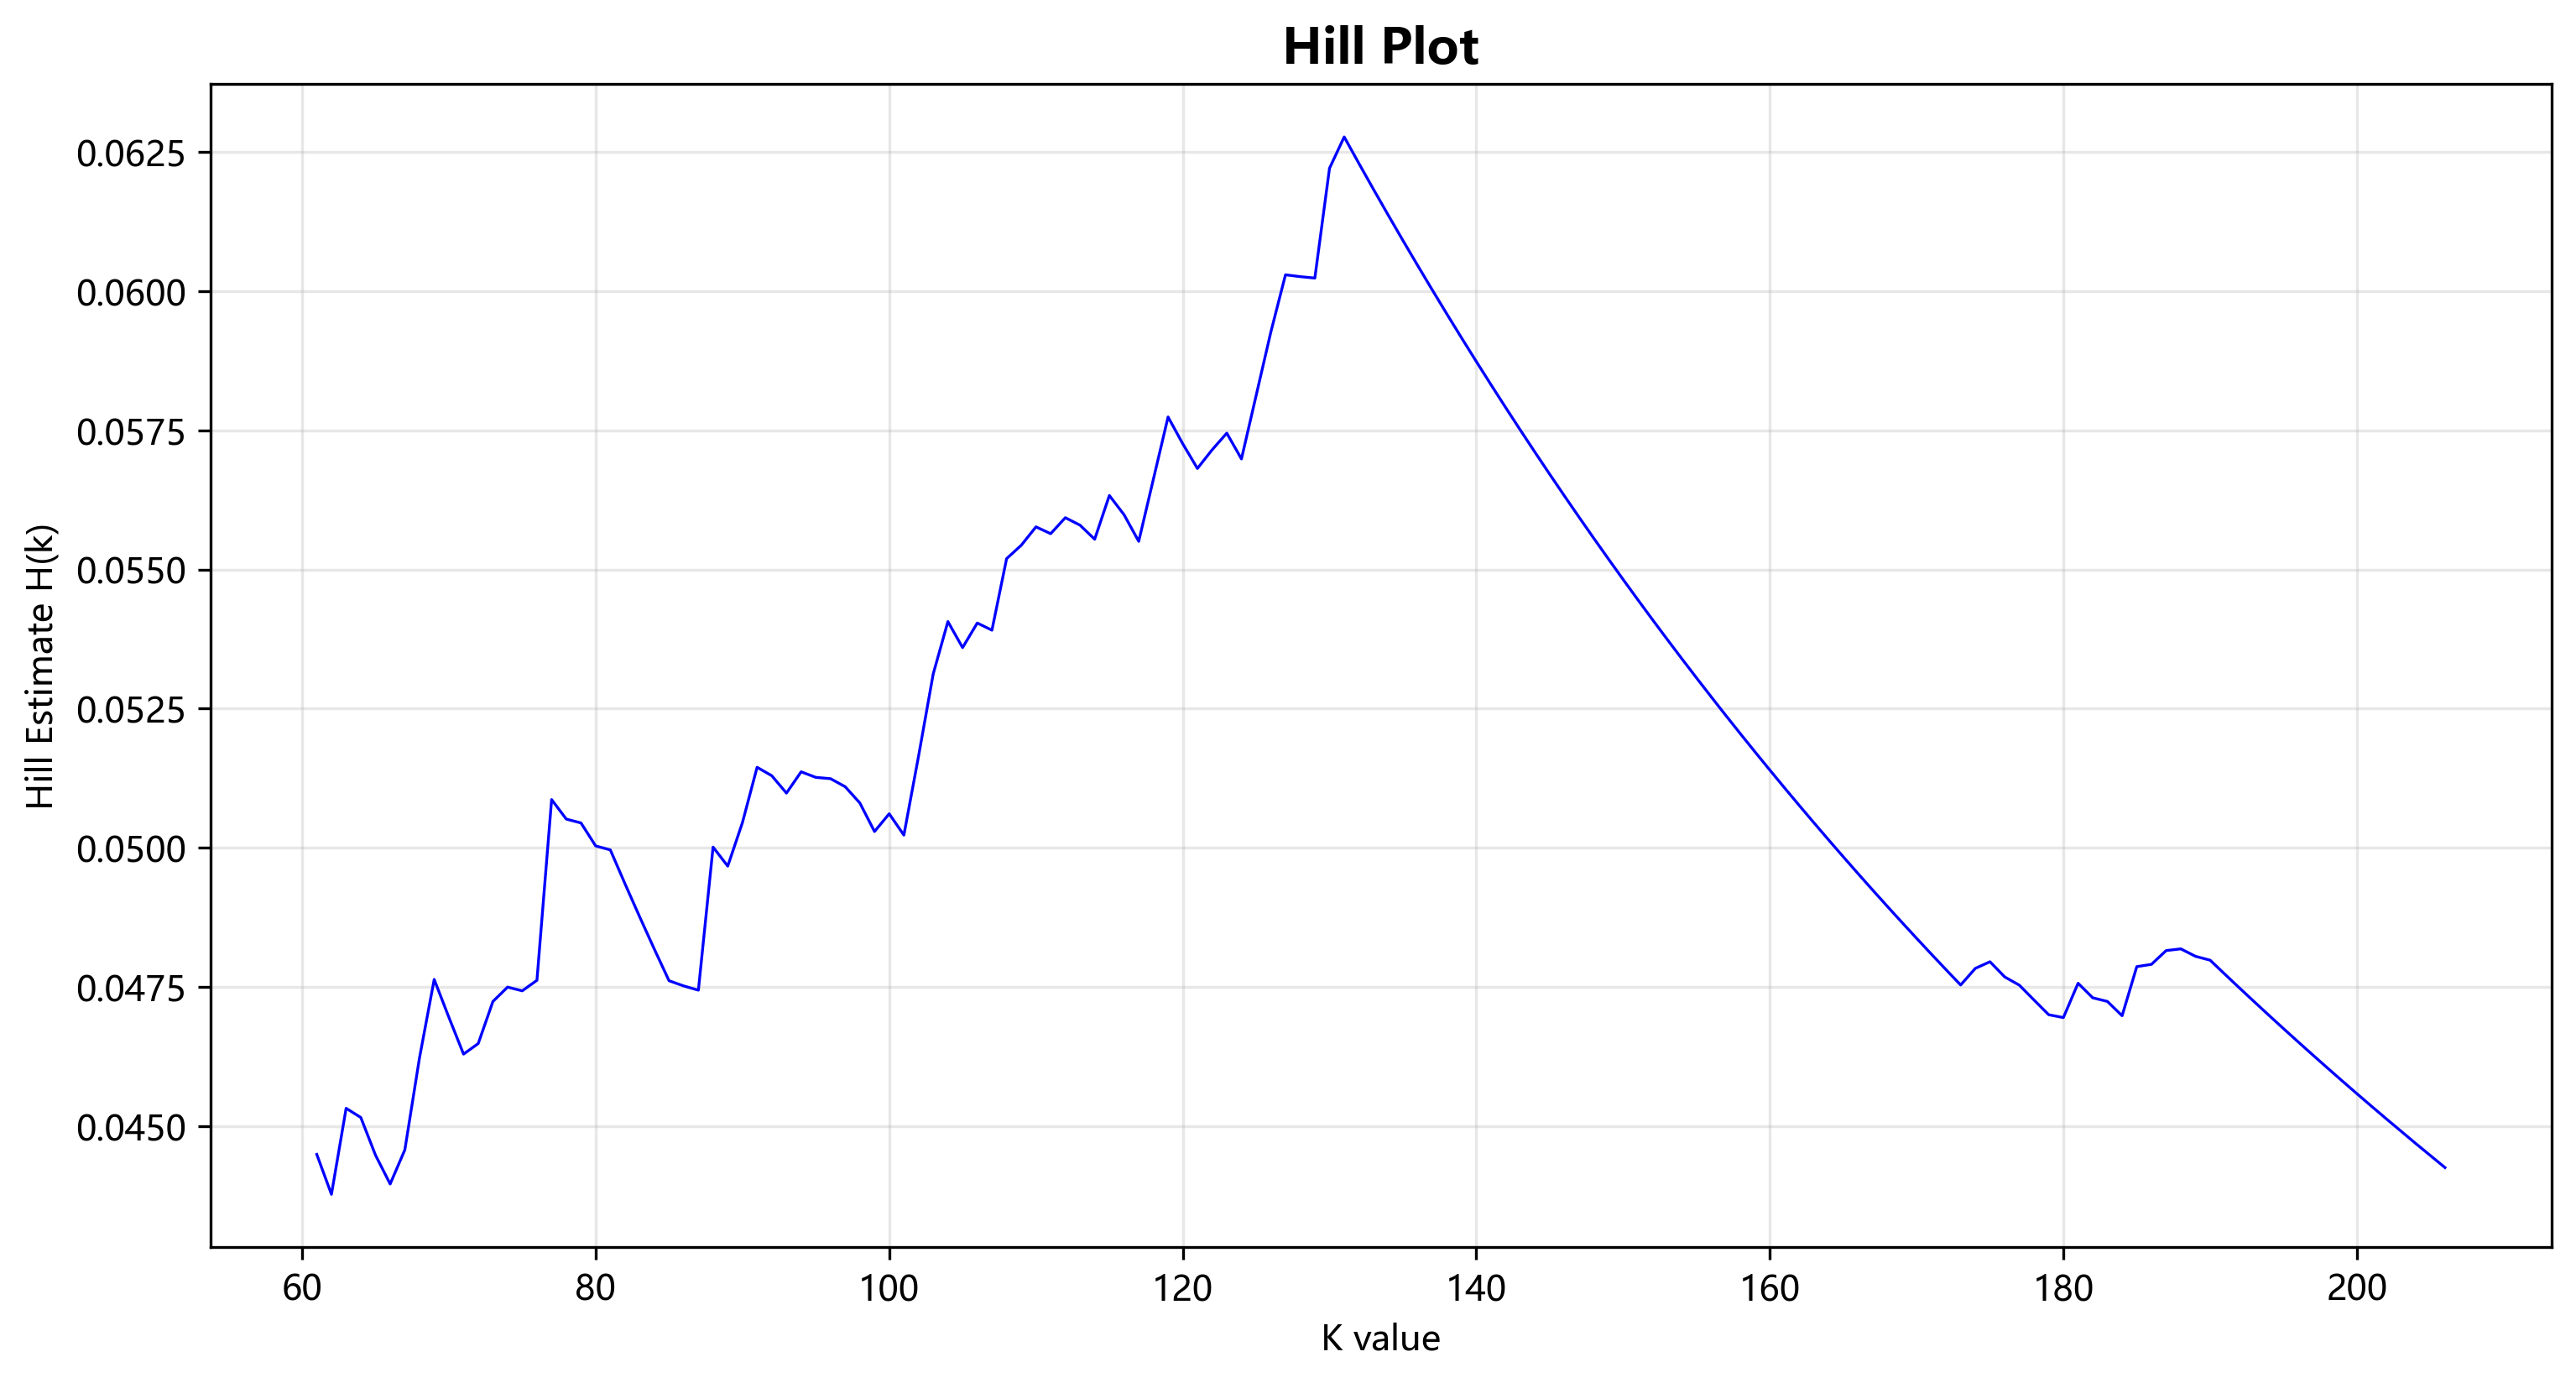

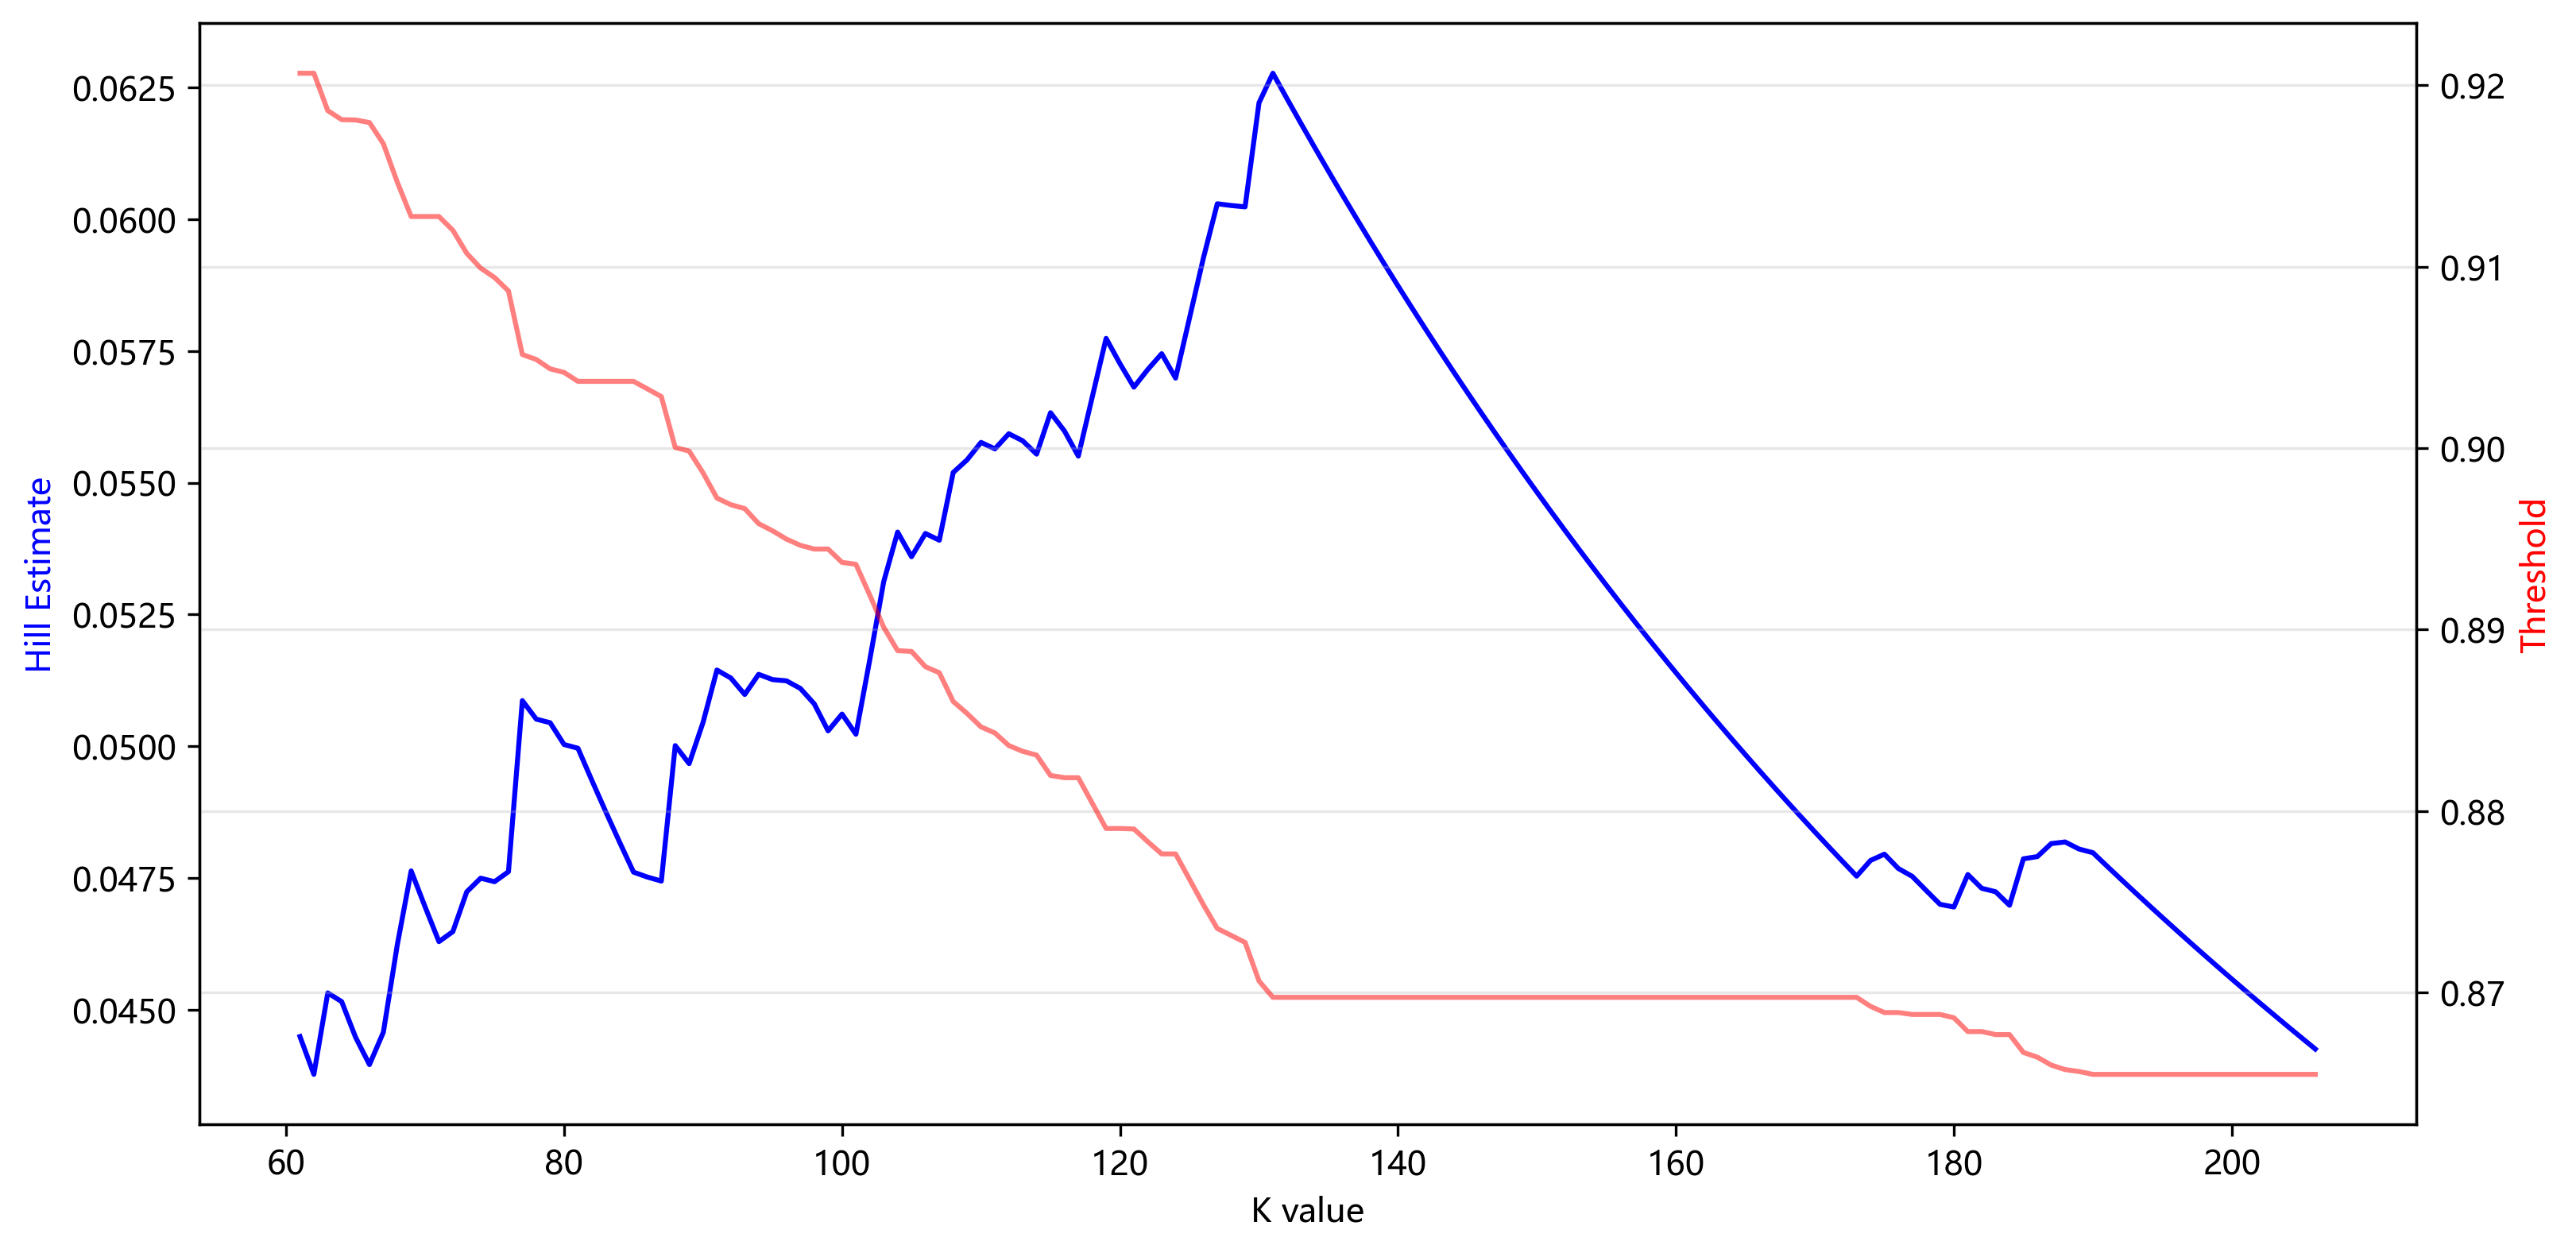

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(k_values, hill_estimates, 'b-', linewidth=0.8)
plt.xlabel('K value')
plt.ylabel('Hill Estimate H(k)')
plt.title('Hill Plot', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

# 同时画阈值变化
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
ax1.plot(k_values, hill_estimates, 'b-', label='Hill H(k)')
ax2.plot(k_values, thresholds, 'r-', alpha=0.5, label='Threshold')
ax1.set_xlabel('K value')
ax1.set_ylabel('Hill Estimate', color='b')
ax2.set_ylabel('Threshold', color='r')
# plt.title('Hill Estimate vs Threshold', fontsize=14)
plt.grid(True, alpha=0.3)
plt.savefig('hill_estimates.pdf', dpi=300)
plt.show()

In [25]:
# 简化版本：只创建DataFrame并输出
hill_df = pd.DataFrame({
    'k': k_values,
    'threshold': thresholds,
    'hill_estimate': hill_estimates
})

# 设置显示选项，避免科学计数法
pd.set_option('display.float_format', '{:.6f}'.format)
pd.set_option('display.max_rows', 20)

# 输出完整DataFrame
print(hill_df)

# 保存到文件
hill_df.to_csv('hill_results.csv', index=False)
print(f"\n结果已保存，共{len(hill_df)}行数据")

       k  threshold  hill_estimate
0     20   0.971997       0.018781
1     21   0.971409       0.018492
2     22   0.971300       0.017763
3     23   0.968925       0.019440
4     24   0.968859       0.018697
..   ...        ...            ...
182  202   0.865484       0.045129
183  203   0.865484       0.044907
184  204   0.865484       0.044687
185  205   0.865484       0.044469
186  206   0.865484       0.044253

[187 rows x 3 columns]

结果已保存，共187行数据


## 查找共包含20%的上限值

In [26]:
# 获取 norm_risk_score 列，删除缺失值
scores = df['norm_risk_score'].dropna().values

# 总样本量
n = len(scores)

# 目标区间样本量（占总体的20%）
target_count = int(n * 0.2)

# 排序（升序）
sorted_scores = np.sort(scores)

num = 0.8716
# 找到 指定数 在排序中的位置
# 方法：找到第一个 >= 指定数 的位置
start_idx = np.searchsorted(sorted_scores, num, side='left')

# 计算终点位置
end_idx = start_idx + target_count

# 检查是否越界
if end_idx >= n:
    print(f"警告：区间超出数据范围！终点索引 {end_idx} >= 总样本量 {n}")
    end_idx = n - 1
    upper_threshold = sorted_scores[-1]
else:
    upper_threshold = sorted_scores[end_idx]

# 区间内的实际样本数
actual_count = end_idx - start_idx
actual_ratio = actual_count / n * 100

print(f"总样本量: {n:,}")
print(f"{num} 的位置索引: {start_idx} (占比 {start_idx/n*100:.2f}%)")
print(f"目标区间样本数: {target_count:,} (20%)")
print(f"实际区间样本数: {actual_count:,} ({actual_ratio:.2f}%)")
print(f"区间上限值: {upper_threshold:.6f}")
print(f"区间范围: [{num}, {upper_threshold:.6f}]")

# 验证区间内的样本比例
in_interval = (scores >= 0.55) & (scores <= upper_threshold)
actual_ratio_verify = in_interval.sum() / n * 100
print(f"验证 - 实际落在区间内的比例: {actual_ratio_verify:.2f}%")

警告：区间超出数据范围！终点索引 2473341 >= 总样本量 2061226
总样本量: 2,061,226
0.8716 的位置索引: 2061096 (占比 99.99%)
目标区间样本数: 412,245 (20%)
实际区间样本数: 129 (0.01%)
区间上限值: 1.000000
区间范围: [0.8716, 1.000000]
验证 - 实际落在区间内的比例: 1.18%


In [28]:
print(df['norm_risk_score'].quantile(0.9999))

0.8654834424103703


# 计算赔款与保费

In [29]:
lower_limit = 0.8716   # 下限，可自行修改
target = 1000000 # 自行设置保额
df = pd.read_parquet('features_with_riskindex.parquet')
scores = df['norm_risk_score'].values

# 向量化计算赔款（避免循环）
# 处理缺失值：先转为float，np.where 自动跳过nan
scores_float = scores.astype(float)

# 计算 (score - lower) / (1 - lower)
# 对于 score <= lower 的情况，赔款设为 0
denominator = 1.0 - lower_limit
rate = np.minimum((scores_float - lower_limit) / denominator, 0.8)
if denominator <= 0:
    raise ValueError("下限不能 >= 1，否则分母为0或负数")

# 向量化计算
claims = rate * target
# 将低于下限的赔款置为0
claims = np.where(scores_float <= lower_limit, 0.0, claims)

# 计算保费 = 1.2 * 赔款
premiums = claims * 1.2

# 添加新列到df
df['claim_amount'] = claims
df['premium_amount'] = premiums

print(f"计算完成，共处理 {len(df):,} 行")
print(f"下限值: {lower_limit}")
print(f"赔款范围: [{claims.min():.6f}, {claims.max():.6f}]")
print(f"保费范围: [{premiums.min():.6f}, {premiums.max():.6f}]")
print(f"零赔款样本数: {(claims == 0).sum():,} (占比 {(claims==0).mean()*100:.2f}%)")

计算完成，共处理 2,061,226 行
下限值: 0.8716
赔款范围: [0.000000, 800000.000000]
保费范围: [0.000000, 960000.000000]
零赔款样本数: 2,061,096 (占比 99.99%)


In [31]:
# 查看某个赔款值对应的数量
target_claim = 800000
count = (claims == target_claim).sum()
ratio = count / len(claims) * 100
print(f"赔款 = {target_claim}: {count:,} 条 ({ratio:.2f}%)")

# 查看大于某个值的
threshold = 700000
count = (claims > threshold).sum()
ratio = count / len(claims) * 100
print(f"赔款 > {threshold}: {count:,} 条 ({ratio:.2f}%)")

赔款 = 800000: 19 条 (0.00%)
赔款 > 700000: 32 条 (0.00%)


## 保存新文件

In [ ]:
# # 保存新文件（输出路径自行修改）
# df.to_parquet('with_payoff_premium.parquet', index=False)
# print(f"新文件保存至:'with_payoff_premium.parquet'")

# 聚合赔款记录

In [32]:
# 假设 df 已经包含 'month', 'day', 'claim_amount' 列
# 按 month, day 分组，取 claim_amount 最大的行
idx = df.groupby(['month', 'day'])['claim_amount'].idxmax()
daily_max_df = df.loc[idx, ['month', 'day', 'claim_amount']].reset_index(drop=True)

print(f"共 {len(daily_max_df)} 天的记录")
print(daily_max_df.head())

共 89 天的记录
   month  day  claim_amount
0      3    1      0.000000
1      3    2      0.000000
2      3    3      0.000000
3      3    4      0.000000
4      3    5      0.000000
